In [ ]:
df = pd.read_csv(
    'dataset.csv',
    # nrows=100000
    )
df = df.dropna(subset=['DEP_DELAY'])

display(df)

,Unnamed: 0,FL_DATE,OP_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,CRS_ARR_TIME,...,ORIGIN_DEGREES_x,DEST_DEGREES_x,TOTAL_DELAY_FRM_CATEGORIES,NETT_DELAY,WEIGHT_y,ORIGIN_DEGREES_y,DEST_DEGREES_y,ARR_DELAY_TAG,DEP_DELAY_TAG,DELAY_TAG
0,0,2018-01-01,UA,2429,EWR,DEN,1517,1512.0,-5.0,1745,...,95,164,0.0,-28.0,3130,95,164,False,False,False
1,1,2018-01-01,UA,2427,LAS,SFO,1115,1107.0,-8.0,1254,...,117,87,0.0,-32.0,7883,117,87,False,False,False
2,2,2018-01-01,UA,2426,SNA,DEN,1335,1330.0,-5.0,1649,...,24,164,0.0,-18.0,3593,24,164,False,False,False
3,3,2018-01-01,UA,2425,RSW,ORD,1546,1552.0,6.0,1756,...,47,175,0.0,4.0,2347,47,175,False,False,False
4,4,2018-01-01,UA,2424,ORD,ALB,630,650.0,20.0,922,...,174,20,0.0,34.0,2011,174,20,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7213441,7213441,2018-12-31,AA,1815,DCA,CLT,1534,1530.0,-4.0,1714,...,90,136,0.0,-9.0,3252,90,136,False,False,False
7213442,7213442,2018-12-31,AA,1816,CLT,DFW,1751,1757.0,6.0,1952,...,136,169,0.0,7.0,3722,136,169,False,False,False
7213443,7213443,2018-12-31,AA,1817,CLT,MEM,2015,2010.0,-5.0,2107,...,136,30,0.0,6.0,2194,136,30,True,False,True
7213444,7213444,2018-12-31,AA,1818,CLT,RDU,1300,1323.0,23.0,1350,...,136,57,0.0,37.0,3173,136,57,True,True,True


In [15]:
features = [
            # 'FL_DATE', 
              'OP_CARRIER', 
            #   'OP_CARRIER_FL_NUM', 
              'ORIGIN', 
              'DEST',
            #   'CRS_DEP_TIME', # use planned departure time 
              # 'DEP_TIME', 
            #   'DEP_DELAY', 
              # 'CRS_ARR_TIME', 
            #   'ARR_TIME',
            #   'ARR_DELAY', 
            #   'CANCELLED', 
            #   'CANCELLATION_CODE', 
            #   'DIVERTED',
            #   'CRS_ELAPSED_TIME',
            #   'ACTUAL_ELAPSED_TIME', 
            #   'AIR_TIME', 
            #   'DISTANCE',
            #   'CARRIER_DELAY', 
            #   'WEATHER_DELAY', 
            #   'NAS_DELAY', 
            #   'SECURITY_DELAY',
            #   'LATE_AIRCRAFT_DELAY', 
            #   'DEP_TIME_MINUTES', 
            #   'ARR_TIME_MINUTES',
            #   'ACTUAL_ELAPSED_TIME_MINUTES', 
            #   'CRS_DEP_TIME_MINUTES',
            #   'CRS_ARR_TIME_MINUTES', 
            #   'CRS_ELAPSED_TIME_MINUTES', 
              'FL_DATE_MONTH',
              'FL_DATE_DAY', 
              'FL_TIME',
              'FL_DATE_WEEK',
              'IS_WEEKEND',
            #   'WEIGHT',
            #   'ORIGIN_DEGREES',
            #   'DEST_DEGREES',
            #   'TOTAL_DELAY_FRM_CATEGORIES',
            #   'NETT_DELAY', 
            #   'ARR_DELAY_TAG', 
            #   'DEP_DELAY_TAG', 
            #   'DELAY_TAG'
              ]


In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from category_encoders import TargetEncoder

# CUSTOM TRANSFORMER FOR TIME
class TimeCyclicalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, time_col):
        self.time_col = time_col
        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        # Convert time objects to total minutes from midnight
        # Handles both datetime.time objects and strings
        def get_minutes(t):
            return (t.hour * 60) + t.minute
            
        minutes = X[self.time_col].apply(get_minutes)
        X['dep_time_sin'] = np.sin(2 * np.pi * minutes / 1440)
        X['dep_time_cos'] = np.cos(2 * np.pi * minutes / 1440)
        
        # Drop the original time column so the model doesn't see it
        return X.drop(columns=[self.time_col])

df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['FL_TIME'] = df['FL_DATE'].dt.time 

# Define features
features = ['FL_DATE_MONTH', 'FL_DATE_DAY', 'IS_WEEKEND', 'FL_TIME', 'ORIGIN', 'DEST', 'OP_CARRIER']
X = df[features]
y = df['DEP_DELAY']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# define pipeline
candidate_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6)
}

results = {}
trained_pipelines = {}

for name, model in candidate_models.items():
    # build pipeline
    pipe = Pipeline([
        ('time_enc', TimeCyclicalEncoder(time_col='FL_TIME')),
        ('target_enc', TargetEncoder(cols=['ORIGIN', 'DEST', 'OP_CARRIER'])),
        ('regressor', model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = np.maximum(pipe.predict(X_test), 0)
    
    mae = mean_absolute_error(y_test, preds)
    results[name] = mae
    trained_pipelines[name] = pipe
    print(f"{name} MAE: {mae:.2f}")

# save the best model
best_name = min(results, key=results.get)
joblib.dump(trained_pipelines[best_name], 'final_flight_pipeline.pkl')
print(f"\nSaved the {best_name} pipeline.")

Linear Regression MAE: 20.77
Random Forest MAE: 20.46
XGBoost MAE: 20.40

Saved the XGBoost pipeline.


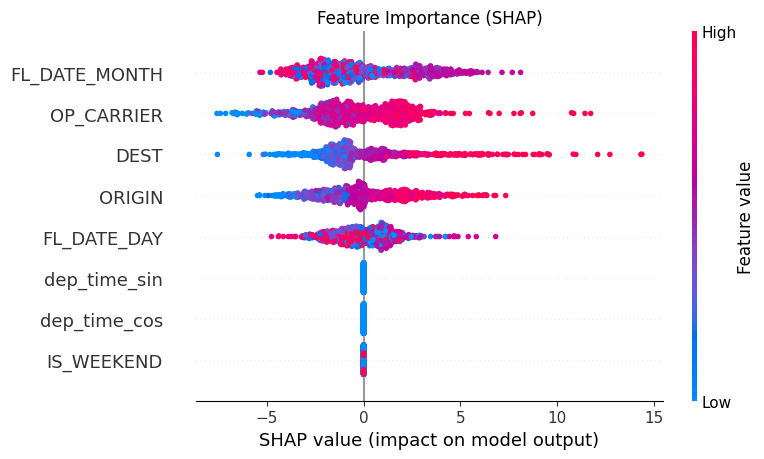

In [21]:
import shap
import matplotlib.pyplot as plt

best_pipe = trained_pipelines["XGBoost"]
model = best_pipe.named_steps['regressor']

X_test_transformed = best_pipe.named_steps['time_enc'].transform(X_test)
X_test_transformed = best_pipe.named_steps['target_enc'].transform(X_test_transformed)

explainer = shap.Explainer(model)
shap_values = explainer(X_test_transformed.iloc[:1000, :])

plt.title("Feature Importance (SHAP)")
shap.summary_plot(shap_values, X_test_transformed.iloc[:1000, :])

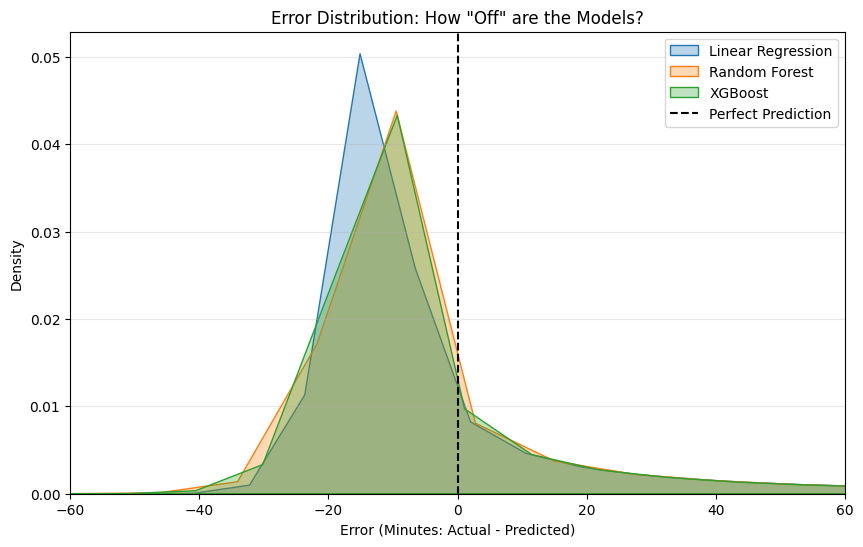

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

for name, pipe in trained_pipelines.items():

    preds = np.maximum(pipe.predict(X_test), 0)
    
    residuals = y_test - preds

    sns.kdeplot(residuals, label=name, fill=True, common_norm=False, alpha=0.3)

plt.axvline(x=0, color='black', linestyle='--', label='Perfect Prediction')
plt.xlim(-60, 60)
plt.xlabel('Error (Minutes: Actual - Predicted)')
plt.ylabel('Density')
plt.title('Error Distribution: How "Off" are the Models?')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
# HI KELLY AND PHILIP!!! USE THIS FOR INFERENCE

import joblib
import pandas as pd
import numpy as np
from datetime import time

from sklearn.base import BaseEstimator, TransformerMixin

class TimeCyclicalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, time_col):
        self.time_col = time_col
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        def get_minutes(t):
            # Handles Python time objects
            return (t.hour * 60) + t.minute
        minutes = X[self.time_col].apply(get_minutes)
        X['dep_time_sin'] = np.sin(2 * np.pi * minutes / 1440)
        X['dep_time_cos'] = np.cos(2 * np.pi * minutes / 1440)
        return X.drop(columns=[self.time_col])

# load model
model_pipeline = joblib.load('final_flight_pipeline.pkl')

# Create a new flight example
# Note that it's a list, so can pass multiple flights or just one
new_flight = pd.DataFrame([{
    'FL_DATE_MONTH': 12,
    'FL_DATE_DAY': 2,
    'IS_WEEKEND': 0,
    'FL_TIME': time(14, 30), # 2:30 PM
    'ORIGIN': 'ORD',
    'DEST': 'LGA',
    'OP_CARRIER': 'UA'
}])

# Run prediction
prediction = model_pipeline.predict(new_flight)
final_result = max(0, prediction[0])

print(f"--- Flight Delay Prediction ---")
print(f"Predicted Departure Delay: {final_result:.1f} minutes")

--- Flight Delay Prediction ---
Predicted Departure Delay: 7.6 minutes
